# Cuaderno 08 — Asociación entre variables, partición temporal y ventanas deslizantes

**Proyecto de Grado — Maestría en Ciencia de Datos**
**Pontificia Universidad Javeriana Cali — Grupo 8**

---

## Qué observación atiende cada sección

| Sección | Punto de la reunión |
|---|---|
| 2. Qué variables son aleatorias y cuáles son deterministas | 20, 21 |
| 3. Tamaño de muestra efectivo bajo autocorrelación | 21 |
| 4. Asociación corregida: Pearson, Spearman y anomalías | 20, 21 |
| 5. Partición temporal con embargo | 22, 25 |
| 6. Esquema didáctico de las ventanas deslizantes | 23 |
| 7. Robustez del desempeño por subperíodo | 22, 25 |
| 8. Predicciones ajustadas a la franja diurna | 24 |

## La idea que ordena todo

La dirección señaló que en una matriz de correlación de Pearson no se pueden meter indicadores
temporales. Tiene razón, y el alcance del problema es mayor de lo que parece: además de las
seis variables cíclicas, hay otras dos entradas del modelo que **no son variables aleatorias
sino funciones deterministas del reloj y del calendario**: el ángulo cenital solar y la
irradiancia de cielo despejado. Correlacionar la respuesta con ellas no mide asociación entre
variables; mide qué tanto la respuesta sigue una plantilla fija.

## 0. Importaciones y estilo

In [ ]:
!pip install pandas numpy matplotlib scipy --quiet

import os, subprocess, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle, FancyArrowPatch
from scipy import stats as sps

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

HORA_INI_DIURNO, HORA_FIN_DIURNO = 6, 18

# El estilo de las figuras (paleta y tamanos de letra) se define en la celda
# siguiente, la celda de estilo, para que sea identico en los 11 cuadernos.
C_A, C_B, C_C = '#2C5F8D', '#D97D2E', '#7A9E3F'
print('Listo:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))


Listo: 2026-09-12 22:11:06


### Estilo unico de figuras

Esta celda fija la **paleta de colores** y los **tamanos de letra** de todas las figuras del cuaderno. Es la misma celda en los once cuadernos, de modo que cualquier figura del trabajo de grado sale con el mismo aspecto.


In [ ]:
# @@ESTILO_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  ESTILO UNICO DE FIGURAS DEL TRABAJO DE GRADO
#  Esta celda define la paleta y la tipografia de TODAS las figuras.
#  Es identica en los 11 cuadernos: cambiarla aqui cambia solo este cuaderno,
#  por eso si se modifica hay que modificarla en todos.
#
#  Paleta categorica anclada en el azul. Validada con el verificador de
#  accesibilidad de color (separacion OKLab bajo protanopia y deuteranopia,
#  piso de croma, banda de luminosidad y contraste contra fondo blanco):
#  todos los pares de colores pasan, no solo los contiguos.
# =============================================================================
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler
try:
    import seaborn as sns
except Exception:
    sns = None

# --- 1. Paleta categorica (orden FIJO: la ranura 1 es siempre la serie principal)
C_AZUL    = '#0C60A3'   # ranura 1 - serie principal / observado / T1 / V1
C_AMBAR   = '#D4771A'   # ranura 2 - segunda serie / modelo / T2 / V2
C_CELESTE = '#269AE6'   # ranura 3 - tercera serie / T3 / V3
C_TEJA    = '#963E35'   # ranura 4 - cuarta serie
C_VERDEAZ = '#0D8F73'   # ranura 5 - quinta serie
PALETA_TG = [C_AZUL, C_AMBAR, C_CELESTE, C_TEJA, C_VERDEAZ]

# --- 2. Tonos de apoyo de la rampa azul (rellenos, bandas, sombreados)
C_AZUL_CLARO  = '#81B4EA'
C_AZUL_MEDIO  = '#5A9BDC'
C_AZUL_OSCURO = '#0A3765'

# --- 3. Tinta neutra: texto, ejes, lineas de referencia. NUNCA es una serie.
C_TEXTO      = '#1A1A1A'
C_GRIS       = '#6E6E6E'
C_GRIS_CLARO = '#C9C9C9'

# --- 4. Mapas de color continuos
#   'tg_azul' : secuencial de un solo tono, claro -> oscuro (magnitudes)
#   'tg_div'  : divergente azul <-> teja con gris neutro en el centro
#               (mantiene la lectura de 'RdBu_r': negativo azul, positivo calido)
_SECUENCIAL = ['#F4F9FF', '#D8E8FA', '#B4D2F4', '#81B4EA', '#5A9BDC',
               '#3581C9', '#1667AC', '#0B4E89', '#0A3765']
_DIVERGENTE = ['#0A3765', '#1667AC', '#5A9BDC', '#AFCEEC', '#F2F1EF',
               '#EFC9AC', '#DC9A5A', '#B4642C', '#7E3A2C']
CMAP_SEC = LinearSegmentedColormap.from_list('tg_azul', _SECUENCIAL)
CMAP_DIV = LinearSegmentedColormap.from_list('tg_div',  _DIVERGENTE)

def _registrar_cmap(cm_obj):
    """Registra el mapa por nombre para poder usar cmap='tg_azul'."""
    try:
        mpl.colormaps.register(cm_obj, force=True)          # matplotlib >= 3.6
    except Exception:
        try:
            mpl.cm.register_cmap(cmap=cm_obj)               # matplotlib antiguo
        except Exception:
            pass

for _c in (CMAP_SEC, CMAP_DIV):
    _registrar_cmap(_c)

def escala_azul(n, ini=0.375, fin=1.0):
    """n colores tomados de la rampa azul. Para variables ORDENADAS (anios,
    meses, horizontes): el orden se lee en el tono, de claro a oscuro."""
    if n <= 1:
        return [C_AZUL]
    paso = (fin - ini) / (n - 1)
    return [CMAP_SEC(ini + i * paso) for i in range(n)]

# --- 6. Eje X de fechas legible ----------------------------------------------
import matplotlib.dates as mdates

def eje_fechas(ax):
    """Ajusta el eje X de fechas al rango real de la serie: anios cuando abarca
    anios, meses cuando abarca meses. Evita que se repita la misma etiqueta
    ('2023 2023 2023 ...') cuando el periodo es corto."""
    loc = mdates.AutoDateLocator(minticks=4, maxticks=9)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    return ax

# --- 7. Trazo por serie: si dos curvas se superponen, el trazo las separa -----
ESTILOS_TG = ['-', '--', ':', '-.', (0, (5, 1, 1, 1))]
TRAZO = {'T1': '-', 'T2': '--', 'T3': ':',
         'V1': '-', 'V2': '--', 'V3': ':'}

# --- 5. Tipografia: tamanos grandes para que la figura se lea en el PDF impreso
TAM_BASE = 13          # texto general dentro de la figura
TAM_EJE  = 14          # etiquetas de los ejes X e Y
TAM_TICK = 12          # numeros de los ejes
TAM_TIT  = 14.5        # titulo del panel
TAM_LEY  = 12          # leyenda

plt.rcParams.update({
    # --- color
    'axes.prop_cycle'   : cycler(color=PALETA_TG),
    'image.cmap'        : 'tg_azul',
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'savefig.facecolor' : 'white',
    # --- tipografia (lo que pidio la revision: ejes y etiquetas legibles)
    'font.family'       : 'sans-serif',
    'font.size'         : TAM_BASE,
    'axes.titlesize'    : TAM_TIT,
    'axes.labelsize'    : TAM_EJE,
    'axes.titleweight'  : 'bold',
    'axes.labelweight'  : 'normal',
    'xtick.labelsize'   : TAM_TICK,
    'ytick.labelsize'   : TAM_TICK,
    'legend.fontsize'   : TAM_LEY,
    'legend.title_fontsize': TAM_LEY,
    'figure.titlesize'  : TAM_TIT + 1.5,
    # --- trazos y ejes discretos
    'lines.linewidth'   : 1.8,
    'lines.markersize'  : 5.5,
    'axes.linewidth'    : 0.9,
    'axes.edgecolor'    : '#8A8A8A',
    'axes.labelcolor'   : C_TEXTO,
    'text.color'        : C_TEXTO,
    'xtick.color'       : '#8A8A8A',
    'ytick.color'       : '#8A8A8A',
    'xtick.labelcolor'  : C_TEXTO,
    'ytick.labelcolor'  : C_TEXTO,
    'xtick.major.width' : 0.9,
    'ytick.major.width' : 0.9,
    'grid.color'        : C_GRIS_CLARO,
    'grid.linewidth'    : 0.7,
    'grid.alpha'        : 0.55,
    'legend.frameon'    : True,
    'legend.framealpha' : 0.92,
    'legend.edgecolor'  : '#C9C9C9',
    # --- exportacion para Overleaf: el texto viaja como texto dentro del PDF
    'figure.dpi'        : 110,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'svg.fonttype'      : 'path',
})

if sns is not None:
    sns.set_palette(PALETA_TG)

print('Estilo de figuras aplicado.')
print(f'  Paleta categorica: {", ".join(PALETA_TG)}')
print(f'  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)')
print(f'  Tamanos: ejes {TAM_EJE} pt, numeros {TAM_TICK} pt, leyenda {TAM_LEY} pt')

# --- Nombres que usa este cuaderno, atados a la paleta unica ---------------
C_A, C_B, C_C = C_AZUL, C_AMBAR, C_CELESTE


Estilo de figuras aplicado.
  Paleta categorica: #0C60A3, #D4771A, #269AE6, #963E35, #0D8F73
  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)
  Tamanos: ejes 14 pt, numeros 12 pt, leyenda 12 pt


In [ ]:
# @@RUTAS_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  DONDE VIVE EL PROYECTO
#
#  En el Drive hay mas de una copia del proyecto: la del semestre anterior y la
#  actual. Antes cada cuaderno buscaba un archivo de datos por todo el Drive y
#  se quedaba con el PRIMERO que aparecia, que no siempre era el de la carpeta
#  correcta; por eso 'figuras', 'figuras_PDF' y 'figuras_SVG' se crearon en la
#  carpeta vieja.
#
#  Ahora la carpeta del proyecto se decide UNA sola vez y de forma explicita:
#  es la carpeta cuyo nombre esta en NOMBRE_CARPETA y cuya ruta contiene
#  CARPETA_PROYECTO. TODO lo que el cuaderno escriba va ahi.
#
#  Si algun dia mueves el proyecto (por ejemplo a 'Proyecto Aplicado IV'),
#  cambias UNA linea: CARPETA_PROYECTO. Y la cambias en los once cuadernos.
# =============================================================================
import os
import subprocess

CARPETA_PROYECTO = 'Proyecto Aplicado III'      # <-- la carpeta actual del semestre
NOMBRE_CARPETA   = 'Codigos Trabajo de Grado'   # <-- nombre de la carpeta de codigo
RAIZ_DRIVE       = '/content/drive/MyDrive'

# Rutas que nunca se usan como carpeta del proyecto, aunque coincidan de nombre.
EXCLUIR_RUTAS = ['/anterior/', '/.Trash', '/.shortcut-targets-by-id/',
                 '/copia de ', '/copy of ']


def _montar_drive():
    try:
        from google.colab import drive
    except Exception:
        return
    if not os.path.isdir(RAIZ_DRIVE):
        drive.mount('/content/drive')
    else:
        print('Drive ya montado.')


def _find(patron, tipo='f', maxdepth=None, raiz=RAIZ_DRIVE, timeout=300):
    cmd = ['find', raiz]
    if maxdepth is not None:
        cmd += ['-maxdepth', str(maxdepth)]
    cmd += ['-type', tipo, '-name', patron]
    try:
        res = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
    except Exception:
        return []
    return [r for r in res.stdout.strip().split('\n') if r]


def _excluida(ruta):
    r = ruta.lower()
    return any(x.lower() in r for x in EXCLUIR_RUTAS)


def localizar_proyecto():
    """Devuelve la carpeta del proyecto. Falla con un mensaje claro si no la
    encuentra o si encuentra mas de una: nunca elige a ciegas."""
    _montar_drive()

    candidatas = _find(NOMBRE_CARPETA, tipo='d', maxdepth=8)
    if not candidatas:
        candidatas = _find(NOMBRE_CARPETA, tipo='d')
    # Segunda pista: cualquier carpeta que contenga los cuadernos de la cadena.
    for nb in _find('0*_*REVISADO.ipynb', tipo='f', maxdepth=9):
        d = os.path.dirname(nb)
        if d not in candidatas:
            candidatas.append(d)

    validas   = [c for c in candidatas if CARPETA_PROYECTO in c and not _excluida(c)]
    descartes = [c for c in candidatas if c not in validas]

    if len(validas) == 1:
        print(f'Carpeta del proyecto: {validas[0]}')
        if descartes:
            print(f'  ({len(descartes)} carpeta(s) descartada(s) por no estar en '
                  f'"{CARPETA_PROYECTO}")')
        return validas[0]

    print('\n' + '=' * 78)
    print('NO SE PUDO DECIDIR LA CARPETA DEL PROYECTO')
    print('=' * 78)
    print(f'  Se busca:  una carpeta "{NOMBRE_CARPETA}" cuya ruta contenga '
          f'"{CARPETA_PROYECTO}"')
    print(f'  Encontradas: {len(candidatas)}')
    for c in candidatas:
        marca = 'SIRVE     ' if c in validas else 'descartada'
        print(f'    [{marca}] {c}')
    print()
    if not validas:
        print('  Que hacer: comprueba el nombre exacto de la carpeta en Drive y ajusta')
        print('  arriba CARPETA_PROYECTO o NOMBRE_CARPETA. Si moviste el proyecto,')
        print('  recuerda cambiarlo en los once cuadernos.')
    else:
        print('  Hay varias carpetas que sirven. Escribe arriba una CARPETA_PROYECTO')
        print('  mas especifica, por ejemplo la ruta completa desde MyDrive.')
    print('=' * 78 + '\n')
    raise FileNotFoundError(
        f'No hay exactamente una carpeta "{NOMBRE_CARPETA}" bajo "{CARPETA_PROYECTO}".')


# --- La carpeta del proyecto y todo lo que cuelga de ella --------------------
RUTA_BASE     = localizar_proyecto()
RUTA_DATOS    = os.path.join(RUTA_BASE, 'datos')
RUTA_ARRAYS   = os.path.join(RUTA_DATOS, 'arrays')
RUTA_MODELOS  = os.path.join(RUTA_BASE, 'modelos')
RUTA_RES      = os.path.join(RUTA_BASE, 'resultados')
RUTA_FIGS     = os.path.join(RUTA_BASE, 'figuras')       # PNG
RUTA_FIGS_SVG = os.path.join(RUTA_BASE, 'figuras_SVG')   # SVG
RUTA_FIGS_PDF = os.path.join(RUTA_BASE, 'figuras_PDF')   # PDF, el de Overleaf

for _d in (RUTA_DATOS, RUTA_ARRAYS, RUTA_MODELOS, RUTA_RES,
           RUTA_FIGS, RUTA_FIGS_SVG, RUTA_FIGS_PDF):
    os.makedirs(_d, exist_ok=True)


def archivo_de_datos(nombre, obligatorio=True, pista=''):
    """Localiza un archivo de ENTRADA.

    Primero lo busca dentro de la carpeta del proyecto. Solo si no esta lo busca
    en el resto del Drive, y en ese caso avisa en grande: significa que ese
    archivo se quedo en la carpeta vieja y conviene copiarlo.
    Lo que el cuaderno ESCRIBE nunca sale de la carpeta del proyecto.
    """
    for sub in ('datos', os.path.join('datos', 'arrays'), '', 'resultados', 'modelos'):
        cand = os.path.join(RUTA_BASE, sub, nombre) if sub else os.path.join(RUTA_BASE, nombre)
        if os.path.exists(cand):
            return cand

    fuera = _find(nombre, tipo='f')
    if fuera:
        fuera.sort(key=lambda r: os.path.getmtime(r), reverse=True)
        elegido = fuera[0]
        print('\n' + '!' * 78)
        print(f'AVISO: "{nombre}" no esta en la carpeta del {CARPETA_PROYECTO}.')
        print(f'  Se leera de: {elegido}')
        print(f'  Copialo a  : {RUTA_DATOS}')
        print('  Mientras siga en dos sitios, corres el riesgo de leer una version vieja.')
        print('!' * 78 + '\n')
        return elegido

    if obligatorio:
        raise FileNotFoundError(
            f'No se encontro "{nombre}" ni en la carpeta del proyecto ni en el resto '
            f'del Drive.\n  Carpeta del proyecto: {RUTA_BASE}\n  {pista}')
    return None


print(f'  datos      : {RUTA_DATOS}')
print(f'  figuras    : {RUTA_FIGS} (+ _SVG y _PDF)')
print(f'  modelos    : {RUTA_MODELOS}')
print(f'  resultados : {RUTA_RES}')

# --- Entradas propias de este cuaderno ---------------------------------------
# El conjunto que se analiza es el que gano la validacion del cuaderno 09.
_ruta_tec = os.path.join(RUTA_DATOS, 'tecnica_imputacion.txt')
if os.path.exists(_ruta_tec):
    with open(_ruta_tec, 'r', encoding='utf-8') as _f:
        _tec = _f.read().strip()
    print(f'Conjunto analizado: dataset_final_{_tec}.csv (decidido en el 09).')
else:
    _tec = 'interpolacion'
    print('AVISO: sin tecnica_imputacion.txt; se analiza la interpolacion.')
RUTA_CSV = archivo_de_datos(f'dataset_final_{_tec}.csv',
                            pista='Lo genera el cuaderno 02.')

df = pd.read_csv(RUTA_CSV, index_col='timestamp', parse_dates=True)
MASK_DIURNO = (df.index.hour >= HORA_INI_DIURNO) & (df.index.hour <= HORA_FIN_DIURNO)
print('Registros:', f'{len(df):,}', '| Variables:', df.shape[1])
print('Columnas:', df.columns.tolist())


Mounted at /content/drive
Carpeta del proyecto: /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado
  datos      : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/datos
  figuras    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras (+ _SVG y _PDF)
  modelos    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/modelos
  resultados : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/resultados
Conjunto analizado: dataset_final_kalman.csv (decidido en el 09).
Registros: 1,330,560 | Variables: 25
Columnas: ['RS', 'hora', 'minuto', 'dia_semana', 'dia_anio', 'mes', 'anio', 'sin_hora', 'cos_hora', 'sin_dia_anio', 'cos_dia_anio', 'sin_mes', 'cos_mes', 'es_diurno', 'ALLSKY_

### Figuras en PNG, SVG y PDF

**Añadido en la revisión.** Todas las figuras de este cuaderno se guardan ahora en los tres
formatos, con el mismo nombre y en tres carpetas paralelas: `figuras/` para el PNG,
`figuras_SVG/` para el vectorial editable y `figuras_PDF/` para el que se incluye en Overleaf.

En LaTeX se incluye sin extensión, y así el compilador elige el formato adecuado:

```latex
\includegraphics[width=\linewidth]{figuras_PDF/fig_01b_distribucion}
```

In [ ]:
# --- Guardado de figuras en los tres formatos ----------------------------
#
# El documento se compila en Overleaf, que incluye las figuras en PDF, pero
# conviene tener tambien el SVG (editable) y el PNG (vista rapida y para
# presentaciones). Antes cada cuaderno guardaba en un formato distinto: unos en
# SVG, otros en PDF, otros en PNG. Ahora todos usan esta funcion y producen los
# tres, con el mismo nombre, en tres carpetas paralelas:
#
#   figuras/       nombre.png   300 ppp
#   figuras_SVG/   nombre.svg   vectorial editable
#   figuras_PDF/   nombre.pdf   el que se incluye en LaTeX
#
# En LaTeX basta con \includegraphics{figuras_PDF/nombre} sin extension.
import os
import matplotlib.pyplot as plt

FORMATOS_FIGURA = (
    ('RUTA_FIGS',     'png', {'dpi': 300}),
    ('RUTA_FIGS_SVG', 'svg', {}),
    ('RUTA_FIGS_PDF', 'pdf', {}),
)


def guardar_figura(fig, nombre, verbose=True):
    """Guarda la figura en PNG, SVG y PDF. 'nombre' va SIN extension."""
    if fig is None:
        fig = plt.gcf()
    base = os.path.splitext(os.path.basename(str(nombre)))[0]
    rutas = []
    for var, ext, extra in FORMATOS_FIGURA:
        carpeta = globals().get(var)
        if carpeta is None:
            continue
        os.makedirs(carpeta, exist_ok=True)
        ruta = os.path.join(carpeta, f'{base}.{ext}')
        fig.savefig(ruta, bbox_inches='tight', **extra)
        rutas.append(ruta)
    if verbose:
        print(f'  Figura guardada: {base}.png, .svg y .pdf')
    return rutas


print('Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.')
for _v in ('RUTA_FIGS', 'RUTA_FIGS_SVG', 'RUTA_FIGS_PDF'):
    print(f'  {_v:<14} {globals().get(_v)}')

Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.
  RUTA_FIGS      /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras
  RUTA_FIGS_SVG  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_SVG
  RUTA_FIGS_PDF  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_PDF


## 2. Qué variables son aleatorias y cuáles son deterministas

Una variable aleatoria es aquella cuyo valor no queda determinado por el instante en que se
observa. Bajo ese criterio, las dieciocho entradas del modelo se reparten en dos grupos que se
comportan de manera muy distinta en un análisis de asociación.

**Deterministas del tiempo y del lugar.** Su valor se puede calcular con un almanaque y las
coordenadas del sitio, sin observar nada:

- las seis variables cíclicas de hora, día del año y mes;
- el **ángulo cenital solar**, que es pura astronomía;
- la **irradiancia de cielo despejado**, que se obtiene de la geometría solar y de una
  atmósfera de referencia sin nubes.

**Aleatorias.** Su valor depende del estado real de la atmósfera: temperatura, humedad
relativa, precipitación, presión, las dos componentes del viento, la irradiancia satelital
total, el índice de claridad y la propia irradiancia medida.

Esta separación importa por dos motivos. Para el análisis de asociación, porque correlacionar
la respuesta con una función determinista del índice no mide una relación entre dos
fenómenos. Y para leer el diseño de ablación, porque de las tres variables que la configuración
completa añade a la meteorológica, **dos son deterministas**: eso ayuda a explicar por qué no
aportan capacidad predictiva. La comprobación siguiente lo verifica con los datos.

In [ ]:
DETERMINISTAS = ['sin_hora','cos_hora','sin_dia_anio','cos_dia_anio',
                 'sin_mes','cos_mes','SZA','CLRSKY_SFC_SW_DWN']
ALEATORIAS    = ['T2M','RH2M','PRECTOTCORR','WS10M','WD10M','PS',
                 'ALLSKY_SFC_SW_DWN','KT']
DETERMINISTAS = [v for v in DETERMINISTAS if v in df.columns]
ALEATORIAS    = [v for v in ALEATORIAS    if v in df.columns]

# Verificacion: una variable determinista del reloj y del calendario toma
# practicamente el mismo valor en la misma fecha-hora de anios distintos.
print('COMPROBACION DE DETERMINISMO')
print('=' * 74)
print('Desviacion tipica de cada variable DENTRO de cada casilla (mes, dia, hora, minuto),')
print('expresada como fraccion de su desviacion total. Cerca de cero = determinista.')
print()
clave = [df.index.month, df.index.day, df.index.hour, df.index.minute]
filas = []
for v in DETERMINISTAS + ALEATORIAS:
    g = df[v].groupby(clave)
    intra = g.transform('std').mean()
    total = df[v].std()
    filas.append({'variable': v,
                  'grupo': 'determinista' if v in DETERMINISTAS else 'aleatoria',
                  'razon_intra_total': intra / total if total else np.nan})
det = pd.DataFrame(filas).sort_values('razon_intra_total')
print(det.round(4).to_string(index=False))
det.to_csv(os.path.join(RUTA_DATOS, 'tabla_10_determinismo.csv'), index=False)
print()
print('  Las variables con razon cercana a cero repiten su valor anio tras anio en la')
print('  misma fecha y hora: no aportan informacion sobre el estado del cielo de un dia')
print('  concreto, solo sobre la posicion del Sol.')


COMPROBACION DE DETERMINISMO
Desviacion tipica de cada variable DENTRO de cada casilla (mes, dia, hora, minuto),
expresada como fraccion de su desviacion total. Cerca de cero = determinista.

         variable        grupo  razon_intra_total
         sin_hora determinista             0.0000
         cos_hora determinista             0.0000
          cos_mes determinista             0.0000
          sin_mes determinista             0.0000
              SZA determinista             0.0005
     sin_dia_anio determinista             0.0054
     cos_dia_anio determinista             0.0060
CLRSKY_SFC_SW_DWN determinista             0.0263
ALLSKY_SFC_SW_DWN    aleatoria             0.1357
             RH2M    aleatoria             0.2920
              T2M    aleatoria             0.3185
               PS    aleatoria             0.6267
            WS10M    aleatoria             0.6427
      PRECTOTCORR    aleatoria             0.7645
            WD10M    aleatoria             0.7827
        

## 3. Cuántos datos hay realmente

El documento reporta correlaciones con tres cifras decimales sobre cientos de miles de puntos.
Esa precisión es ilusoria: las observaciones de una serie de tiempo no son independientes, y el
número de datos que aporta información nueva es mucho menor que el número de filas.

Una aproximación clásica al **tamaño de muestra efectivo** de dos series autocorrelacionadas es

$$n_{ef} \approx n \cdot \frac{1 - \rho_x(1)\,\rho_y(1)}{1 + \rho_x(1)\,\rho_y(1)}$$

donde $\rho(1)$ es la autocorrelación de retardo uno de cada serie. Con autocorrelaciones
cercanas a uno, el tamaño efectivo cae en varios órdenes de magnitud.

La consecuencia práctica es simple: **el coeficiente sigue siendo válido como descripción, pero
las pruebas de significancia y los intervalos de confianza que lo acompañan no lo son**, porque
suponen observaciones independientes. Por eso en el documento las correlaciones se reportan sin
valor $p$, y se dice por qué.

In [ ]:
def n_efectivo(x, y):
    x, y = pd.Series(x).dropna(), pd.Series(y).dropna()
    idx = x.index.intersection(y.index)
    x, y = x.loc[idx], y.loc[idx]
    rx = x.autocorr(1); ry = y.autocorr(1)
    n = len(x)
    factor = (1 - rx*ry) / (1 + rx*ry)
    return n, max(factor, 0) * n, rx, ry

d = df.loc[MASK_DIURNO]
print('TAMANIO DE MUESTRA EFECTIVO — franja diurna, resolucion de 5 minutos')
print('=' * 88)
print(f'{"Variable":<28}{"n":>12}{"n efectivo":>14}{"rho RS":>10}{"rho var":>10}')
filas = []
for v in ALEATORIAS + DETERMINISTAS:
    n, nef, rx, ry = n_efectivo(d['RS'], d[v])
    filas.append({'variable': v, 'n': n, 'n_efectivo': nef, 'rho_RS': rx, 'rho_var': ry})
    print(f'{v:<28}{n:>12,}{nef:>14,.0f}{rx:>10.4f}{ry:>10.4f}')
pd.DataFrame(filas).to_csv(os.path.join(RUTA_DATOS, 'tabla_10_n_efectivo.csv'), index=False)
print()
print('  Lectura: con este tamanio efectivo, la tercera cifra decimal de un coeficiente')
print('  de correlacion no es informativa. En el documento se reportan dos.')


TAMANIO DE MUESTRA EFECTIVO — franja diurna, resolucion de 5 minutos
Variable                               n    n efectivo    rho RS   rho var
T2M                              720,720        38,659    0.9014    0.9964
RH2M                             720,720        37,742    0.9014    0.9990
PRECTOTCORR                      720,720        38,805    0.9014    0.9960
WS10M                            720,720        37,690    0.9014    0.9991
WD10M                            720,720        39,194    0.9014    0.9950
PS                               720,720        37,701    0.9014    0.9991
ALLSKY_SFC_SW_DWN                720,720        37,721    0.9014    0.9990
KT                               720,720        41,024    0.9014    0.9899
sin_hora                         720,720        45,958    0.9014    0.9764
cos_hora                         720,720        38,237    0.9014    0.9976
sin_dia_anio                     720,720        37,376    0.9014    1.0000
cos_dia_anio                   

## 4. Asociación corregida

Tres cambios respecto del análisis actual.

**Primero, se sacan las variables deterministas de la matriz.** No son candidatas a predictoras
que haya que cribar: son parte del diseño de entrada del modelo y entran siempre. Además, el
seno y el coseno de un mismo ciclo son ortogonales por construcción cuando la serie cubre un
número entero de períodos, de modo que su correlación nula es un hecho aritmético y no un
hallazgo.

**Segundo, se reporta Spearman junto a Pearson.** Pearson mide asociación lineal; Spearman mide
asociación monótona y no exige linealidad ni sensibilidad a valores extremos. Cambiar de una a
otra no resuelve el problema de los indicadores temporales ni el de la independencia, pero sí
el de suponer linealidad donde la relación puede no serlo. Reportar las dos permite ver dónde
la relación se aparta de la recta.

**Tercero, se calcula también sobre las anomalías.** Buena parte de la correlación entre la
irradiancia local y casi cualquier variable meteorológica se debe a que ambas siguen el ciclo
solar. Restando de cada serie su media climatológica se elimina ese conductor común y queda la
asociación informativa: la que existe entre las desviaciones respecto de lo normal.

In [ ]:
def anomalia(s):
    g = s.groupby([s.index.month, s.index.hour, s.index.minute])
    return s - g.transform('mean')

VARS = ALEATORIAS
d = df.loc[MASK_DIURNO]

anom = pd.DataFrame({v: anomalia(d[v]) for v in ['RS'] + VARS})

filas = []
for v in VARS:
    filas.append({
        'variable'        : v,
        'pearson_bruta'   : d['RS'].corr(d[v], method='pearson'),
        'spearman_bruta'  : d['RS'].corr(d[v], method='spearman'),
        'pearson_anomalia': anom['RS'].corr(anom[v], method='pearson'),
        'spearman_anomalia': anom['RS'].corr(anom[v], method='spearman'),
    })
tabla_asoc = pd.DataFrame(filas)
tabla_asoc['brecha_lin'] = (tabla_asoc['spearman_bruta'].abs()
                            - tabla_asoc['pearson_bruta'].abs())
tabla_asoc = tabla_asoc.reindex(tabla_asoc['pearson_bruta'].abs()
                                .sort_values(ascending=False).index)

print('ASOCIACION CON LA IRRADIANCIA MEDIDA — franja diurna, variables aleatorias')
print('=' * 96)
print(tabla_asoc.round(3).to_string(index=False))
tabla_asoc.to_csv(os.path.join(RUTA_DATOS, 'tabla_10_asociacion.csv'), index=False)
print()
print('  brecha_lin positiva y grande = la relacion es monotona pero no lineal, y')
print('  Pearson la subestima.')

# Para referencia, y solo para el texto: asociacion con las deterministas
print()
print('SOLO COMO REFERENCIA — variables deterministas del tiempo y del lugar')
print('-' * 78)
for v in DETERMINISTAS:
    print(f'  {v:<24} Pearson {d["RS"].corr(d[v]):+.3f}   '
          f'Spearman {d["RS"].corr(d[v], method="spearman"):+.3f}')
print('  Estas cifras NO se reportan en la matriz del documento: describen el alineamiento')
print('  de la respuesta con una plantilla fija del calendario, no una asociacion entre')
print('  fenomenos.')


ASOCIACION CON LA IRRADIANCIA MEDIDA — franja diurna, variables aleatorias
         variable  pearson_bruta  spearman_bruta  pearson_anomalia  spearman_anomalia  brecha_lin
ALLSKY_SFC_SW_DWN          0.665           0.734             0.232              0.195       0.068
             RH2M         -0.604          -0.682            -0.070             -0.065       0.077
              T2M          0.581           0.645             0.037              0.030       0.064
            WS10M          0.240           0.303            -0.079             -0.079       0.063
               KT          0.135           0.120             0.176              0.176      -0.015
               PS          0.062           0.070            -0.030             -0.033       0.008
            WD10M         -0.059          -0.169             0.027             -0.013       0.109
      PRECTOTCORR         -0.033          -0.044            -0.035             -0.066       0.011

  brecha_lin positiva y grande = la relaci

  Figura guardada: fig_10a_matriz_correlacion.png, .svg y .pdf


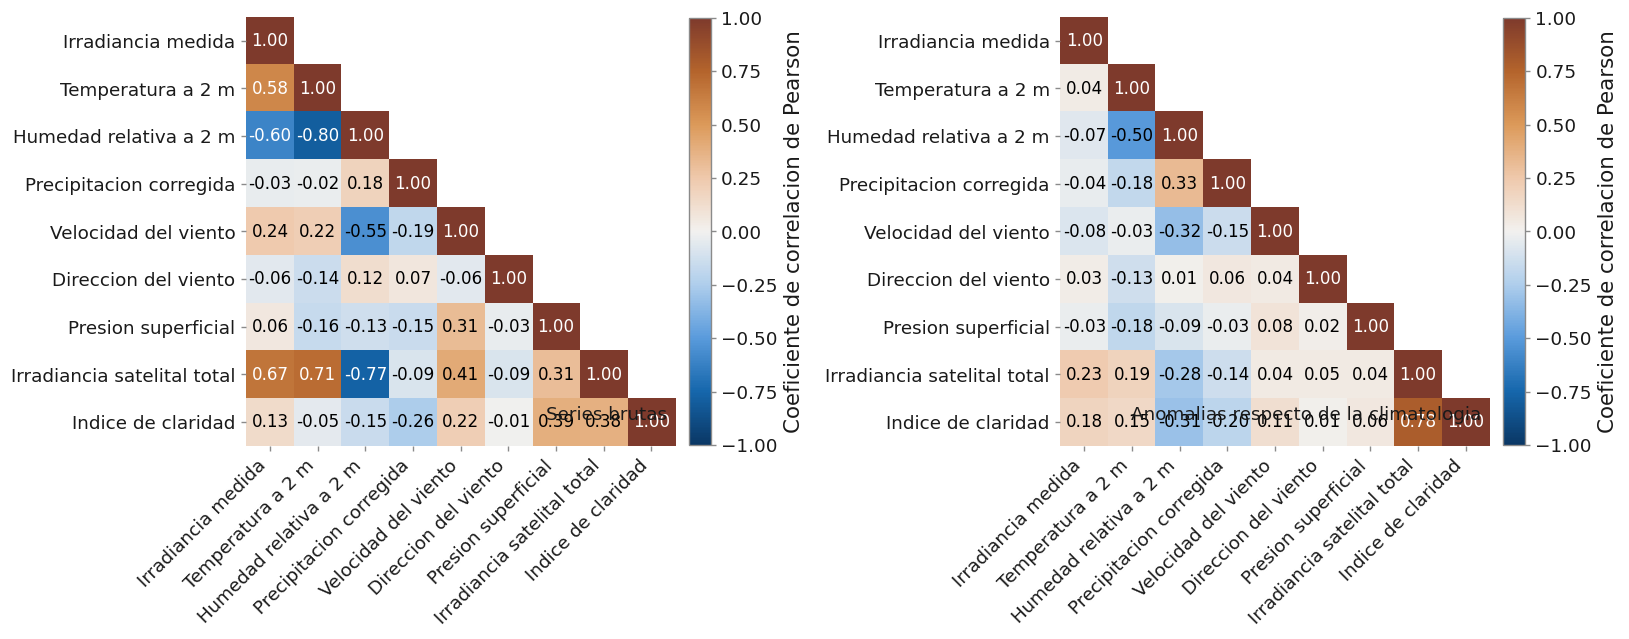

Guardado: fig_10a_matriz_correlacion.pdf


In [ ]:
# Matriz de correlacion solo entre variables aleatorias, con nombres en espaniol
NOMBRES = {
    'RS'               : 'Irradiancia medida',
    'ALLSKY_SFC_SW_DWN': 'Irradiancia satelital total',
    'KT'               : 'Indice de claridad',
    'T2M'              : 'Temperatura a 2 m',
    'RH2M'             : 'Humedad relativa a 2 m',
    'PRECTOTCORR'      : 'Precipitacion corregida',
    'WS10M'            : 'Velocidad del viento',
    'WD10M'            : 'Direccion del viento',
    'PS'               : 'Presion superficial',
}
cols = ['RS'] + VARS
etq  = [NOMBRES.get(c, c) for c in cols]

fig, axes = plt.subplots(1, 2, figsize=(15, 6.4))
for ax, (mat, sub) in zip(axes, [
        (d[cols].corr(method='pearson'),  'Series brutas'),
        (anom[cols].corr(method='pearson'), 'Anomalias respecto de la climatologia')]):
    m = mat.values.copy()
    mask = np.triu(np.ones_like(m, dtype=bool), k=1)
    m[mask] = np.nan
    im = ax.imshow(m, cmap='tg_div', vmin=-1, vmax=1)
    ax.set_xticks(range(len(etq))); ax.set_xticklabels(etq, rotation=45, ha='right')
    ax.set_yticks(range(len(etq))); ax.set_yticklabels(etq)
    for i in range(len(etq)):
        for j in range(i + 1):
            ax.text(j, i, f'{m[i, j]:.2f}', ha='center', va='center', fontsize=11,
                    color='white' if abs(m[i, j]) > 0.55 else 'black')
    ax.text(0.98, 0.06, sub, transform=ax.transAxes, ha='right', fontsize=12)
    for s in ['top', 'right', 'left', 'bottom']:
        ax.spines[s].set_visible(False)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03,
                 label='Coeficiente de correlacion de Pearson')

fig.tight_layout()
guardar_figura(fig, 'fig_10a_matriz_correlacion')
plt.show()
print('Guardado: fig_10a_matriz_correlacion.pdf')


## 5. Partición temporal con embargo

Dos cosas que el documento hace bien y que hay que dejar visibles antes de nada:

1. **La partición ya es cronológica, no aleatoria.** Primero el 70 % más antiguo, luego el
   15 % siguiente, luego el 15 % final. No hay validación cruzada por particiones aleatorias.
2. **Las ventanas se construyen dentro de cada bloque**, sin cruzar las fronteras.

Lo que falta es cerrar el último resquicio. Aunque las ventanas no crucen la frontera, la
última ventana de entrenamiento y la primera de validación están separadas por minutos y son
casi idénticas, porque la serie está autocorrelacionada. Eso hace que una parte pequeña del
conjunto de evaluación sea, en la práctica, una copia de lo ya visto.

La solución estándar es el **embargo**: descartar un tramo entre bloques, de longitud al menos
igual a la ventana de contexto más el horizonte, de modo que ninguna muestra de evaluación
comparta un solo instante con ninguna muestra de entrenamiento. Con un contexto de 288 pasos y
un horizonte máximo de 72, bastan 360 pasos; se adopta un día completo de 288 pasos más el
horizonte, redondeado a **576 pasos, es decir dos días**, que sobre 1,3 millones de registros
supone descartar el 0.04 % de los datos.

In [ ]:
N_TOTAL   = len(df)
L_SEQ, L_LBL, L_PRED_MAX = 288, 144, 72
# --- Limites de la particion ---------------------------------------------
# Se leen de config_fe.pkl si el cuaderno 04 ya se ejecuto, para que la figura
# que va al documento describa la particion real y no una recalculada aqui.
# Si el archivo no existe todavia, se usan los mismos valores del cuaderno 04.
import pickle
_ruta_cfg = os.path.join(RUTA_DATOS, 'arrays', 'config_fe.pkl')
_cfg = None
if os.path.exists(_ruta_cfg):
    with open(_ruta_cfg, 'rb') as _f:
        _cfg = pickle.load(_f)
    if 'embargo' not in _cfg:
        _cfg = None
        print('AVISO: config_fe.pkl no trae embargo (cuaderno 04 antiguo).')
        print('       Se usan los valores por defecto de la revision.')

EMBARGO   = _cfg['embargo'] if _cfg else 576          # dos dias

if _cfg:
    i_tr, i_va = _cfg['idx_train_fin'], _cfg['idx_val_fin']
    print('Particion leida de config_fe.pkl (cuaderno 04).')
else:
    i_tr = int(N_TOTAL * 0.70)
    i_va = int(N_TOTAL * 0.85)
    print('Particion calculada aqui con las proporciones 70/15/15.')

cortes = {
    'Entrenamiento': (0,                  i_tr),
    'Embargo 1'    : (i_tr,               i_tr + EMBARGO),
    'Validacion'   : (i_tr + EMBARGO,     i_va),
    'Embargo 2'    : (i_va,               i_va + EMBARGO),
    'Prueba'       : (i_va + EMBARGO,     N_TOTAL),
}

print('PARTICION CRONOLOGICA CON EMBARGO')
print('=' * 92)
print(f'{"Bloque":<16}{"Desde":<22}{"Hasta":<22}{"Registros":>12}{"%":>8}')
for nom, (a, b) in cortes.items():
    print(f'{nom:<16}{str(df.index[a]):<22}{str(df.index[b-1]):<22}'
          f'{b-a:>12,}{(b-a)/N_TOTAL*100:>8.2f}')
print()
print(f'  Embargo por frontera : {EMBARGO} pasos = {EMBARGO*5/60:.0f} horas')
print(f'  Datos descartados    : {2*EMBARGO:,} de {N_TOTAL:,} '
      f'({2*EMBARGO/N_TOTAL*100:.3f} %)')
print()
print('  Con este margen, la ventana de contexto de la primera muestra de validacion')
print('  empieza despues del ultimo instante que el modelo vio en entrenamiento.')

# Numero de origenes de pronostico en cada bloque
PASO_TR, PASO_EV = 12, 18
for nom, (a, b) in [('Entrenamiento', cortes['Entrenamiento']),
                    ('Validacion',    cortes['Validacion']),
                    ('Prueba',        cortes['Prueba'])]:
    n_pos = max(0, (b - a) - (L_SEQ + L_PRED_MAX))
    paso  = PASO_TR if nom == 'Entrenamiento' else PASO_EV
    print(f'  Ventanas efectivas en {nom:<14}: {n_pos//paso:>8,}')
print()
print('  El conjunto de prueba no es un unico origen de pronostico: cada ventana es un')
print('  origen distinto, y el bloque contiene varios miles. Lo que no varia es el ajuste')
print('  del modelo, que se realiza una sola vez.')


Particion leida de config_fe.pkl (cuaderno 04).
PARTICION CRONOLOGICA CON EMBARGO
Bloque          Desde                 Hasta                    Registros       %
Entrenamiento   2013-08-01 00:00:00   2022-06-08 23:50:00        931,391   70.00
Embargo 1       2022-06-08 23:55:00   2022-06-10 23:50:00            576    0.04
Validacion      2022-06-10 23:55:00   2024-05-01 23:55:00        199,009   14.96
Embargo 2       2024-05-02 00:00:00   2024-05-03 23:55:00            576    0.04
Prueba          2024-05-04 00:00:00   2026-03-25 23:55:00        199,008   14.96

  Embargo por frontera : 576 pasos = 48 horas
  Datos descartados    : 1,152 de 1,330,560 (0.087 %)

  Con este margen, la ventana de contexto de la primera muestra de validacion
  empieza despues del ultimo instante que el modelo vio en entrenamiento.
  Ventanas efectivas en Entrenamiento :   77,585
  Ventanas efectivas en Validacion    :   11,036
  Ventanas efectivas en Prueba        :   11,036

  El conjunto de prueba no es 

  Figura guardada: fig_10b_particion_embargo.png, .svg y .pdf


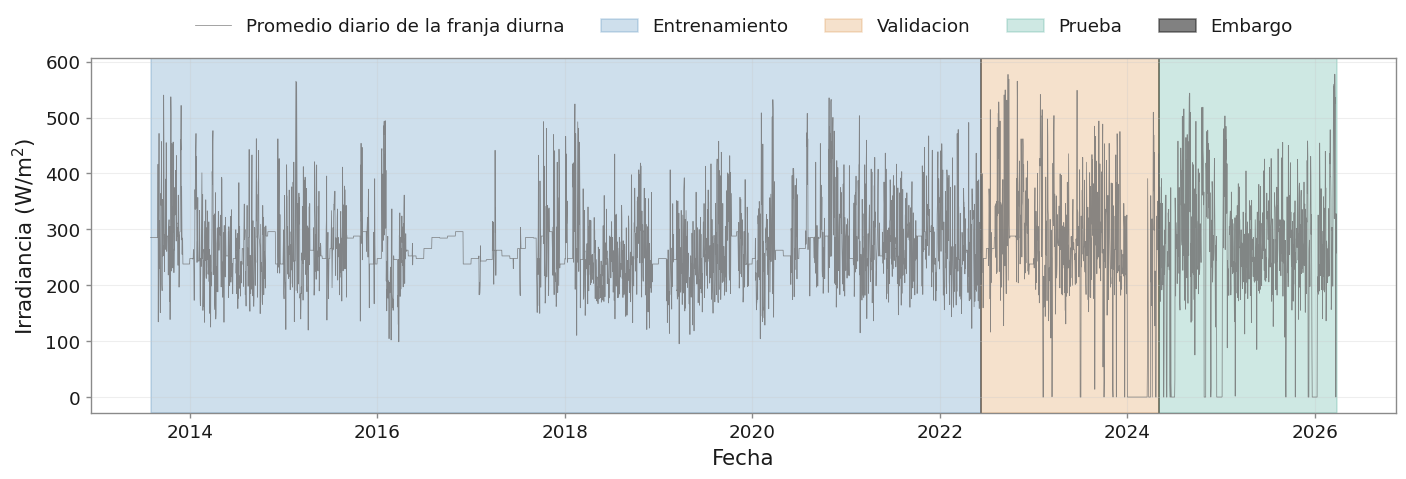

Guardado: fig_10b_particion_embargo.pdf


In [ ]:
# Figura de la particion sobre el promedio diario de la franja diurna
serie_d = df.loc[MASK_DIURNO, 'RS'].resample('D').mean()

fig, ax = plt.subplots(figsize=(13, 4.6))
ax.plot(serie_d.index, serie_d.values, color=C_GRIS, lw=0.5, alpha=0.8,
        label='Promedio diario de la franja diurna')

# Tres bandas de fondo muy claras: aqui lo que separa un bloque de otro no es
# la intensidad sino el TONO, por eso se usan tres tonos bien distintos
# (azul, ambar y verde azulado) y no dos azules, que al aclararse se confunden.
bandas = [('Entrenamiento', C_AZUL, 0.20), ('Validacion', C_AMBAR, 0.22),
          ('Prueba', C_VERDEAZ, 0.20)]
for (nom, color, alpha) in bandas:
    a, b = cortes[nom]
    ax.axvspan(df.index[a], df.index[b-1], color=color, alpha=alpha, label=nom)
for nom in ['Embargo 1', 'Embargo 2']:
    a, b = cortes[nom]
    ax.axvspan(df.index[a], df.index[b-1], color=C_TEXTO, alpha=0.55,
               label='Embargo' if nom == 'Embargo 1' else None)

ax.set_xlabel('Fecha')
ax.set_ylabel('Irradiancia (W/m$^2$)')
ax.legend(frameon=False, ncol=5, loc='upper center', bbox_to_anchor=(0.5, 1.16))
ax.grid(True, alpha=0.3)
eje_fechas(ax)
fig.tight_layout()
guardar_figura(fig, 'fig_10b_particion_embargo')
plt.show()
print('Guardado: fig_10b_particion_embargo.pdf')


## 6. Esquema didáctico de las ventanas deslizantes

El punto 23 pedía dejar claro el tema de las ventanas y acompañarlo con gráficos. La figura
siguiente no lleva datos: es un esquema, y ese es justamente su valor.

La analogía que conviene usar en la sustentación: **imagina que lees un libro por una ventanilla
que solo deja ver unas cuantas líneas a la vez.** Con lo que se ve por la ventanilla hay que
adivinar lo que dice el renglón siguiente. Después se corre la ventanilla un poco hacia
adelante y se repite. Cada posición de la ventanilla es una muestra de entrenamiento.

En esta arquitectura la ventanilla tiene tres partes:

- **contexto**, las 24 horas que el codificador lee completas;
- **prefijo conocido**, las últimas 12 horas de ese contexto, que se le repiten al decodificador
  para que sepa desde dónde continuar;
- **horizonte**, lo que hay que pronosticar, que se entrega en blanco.

Y una cosa más: dos ventanillas consecutivas comparten 287 de sus 288 líneas de contexto, es
decir, son casi la misma muestra. Por eso se avanza de doce en doce pasos en entrenamiento, una
hora, en lugar de uno en uno.

  Figura guardada: fig_10c_esquema_ventanas.png, .svg y .pdf


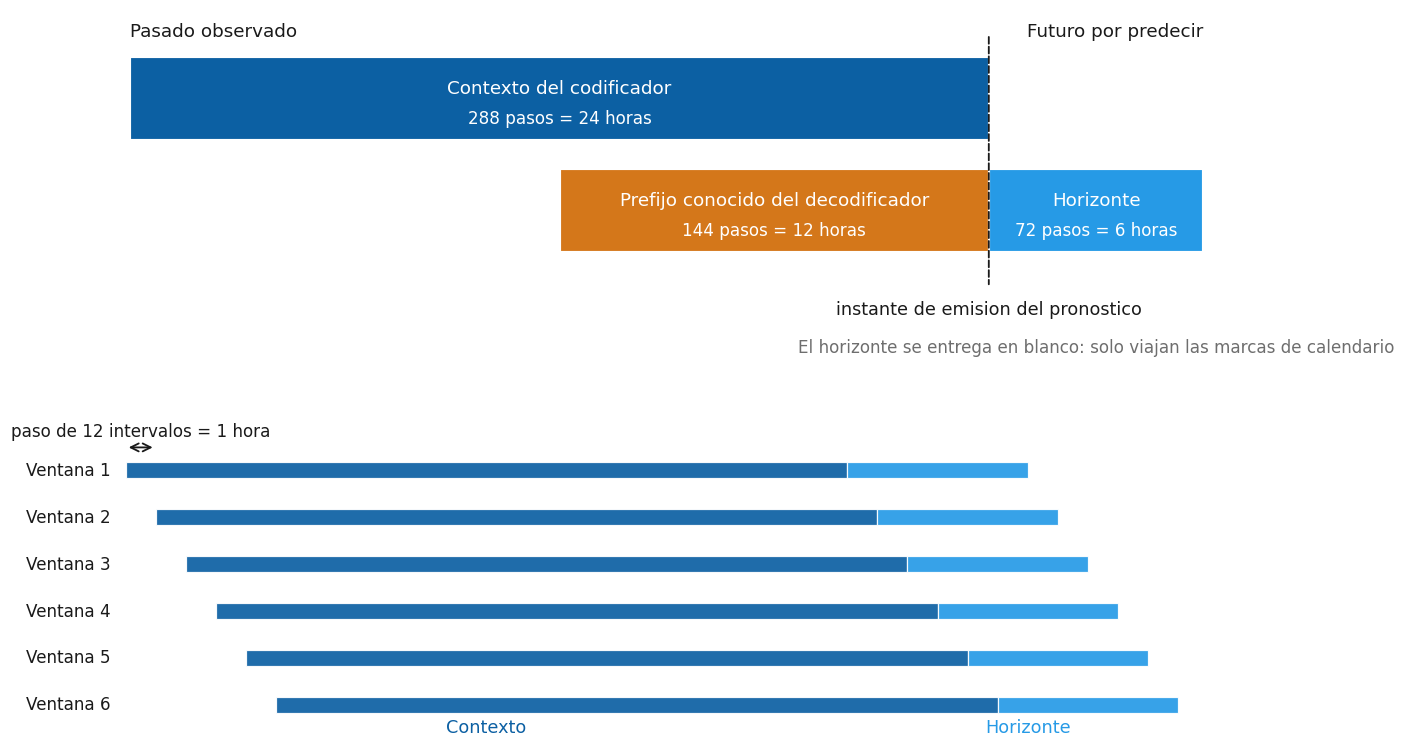

Guardado: fig_10c_esquema_ventanas.pdf


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7),
                         gridspec_kw={'height_ratios': [1.15, 1]})

# --- Panel superior: anatomia de una ventana -------------------------------
ax = axes[0]
ax.set_xlim(-10, L_SEQ + L_PRED_MAX + 10); ax.set_ylim(0, 3.2)
ax.axis('off')

def bloque(ax, x0, ancho, y, alto, color, texto, sub, tcolor='white'):
    ax.add_patch(Rectangle((x0, y), ancho, alto, facecolor=color,
                           edgecolor='white', lw=1.4))
    ax.text(x0 + ancho/2, y + alto/2 + 0.09, texto, ha='center', va='center',
            fontsize=12, color=tcolor)
    ax.text(x0 + ancho/2, y + alto/2 - 0.17, sub, ha='center', va='center',
            fontsize=11, color=tcolor)

bloque(ax, 0, L_SEQ, 2.1, 0.7, C_A,
       'Contexto del codificador',
       f'{L_SEQ} pasos = 24 horas')
bloque(ax, L_SEQ - L_LBL, L_LBL, 1.15, 0.7, C_B,
       'Prefijo conocido del decodificador',
       f'{L_LBL} pasos = 12 horas')
bloque(ax, L_SEQ, L_PRED_MAX, 1.15, 0.7, C_C,
       'Horizonte',
       f'{L_PRED_MAX} pasos = 6 horas')

ax.annotate('', xy=(L_SEQ, 0.85), xytext=(L_SEQ, 3.0),
            arrowprops=dict(arrowstyle='-', ls='--', color=C_TEXTO, lw=1.2))
ax.text(L_SEQ, 0.62, 'instante de emision del pronostico', ha='center', fontsize=11.5,
        color=C_TEXTO)
ax.text(0, 2.98, 'Pasado observado', fontsize=12, color=C_TEXTO)
ax.text(L_SEQ + L_PRED_MAX, 2.98, 'Futuro por predecir', fontsize=12, color=C_TEXTO,
        ha='right')
ax.text(L_SEQ + L_PRED_MAX/2, 0.30,
        'El horizonte se entrega en blanco: solo viajan las marcas de calendario',
        ha='center', fontsize=11, color=C_GRIS)

# --- Panel inferior: ventanas consecutivas y el paso ------------------------
ax = axes[1]
PASO = 12
NV = 6
ax.set_xlim(-10, L_SEQ + L_PRED_MAX + PASO*NV + 10)
ax.set_ylim(-0.4, NV + 0.6)
ax.axis('off')
for i in range(NV):
    x0 = i * PASO
    y  = NV - 1 - i
    ax.add_patch(Rectangle((x0, y + 0.12), L_SEQ, 0.34, facecolor=C_A,
                           edgecolor='white', lw=0.8, alpha=0.92))
    ax.add_patch(Rectangle((x0 + L_SEQ, y + 0.12), L_PRED_MAX, 0.34, facecolor=C_C,
                           edgecolor='white', lw=0.8, alpha=0.92))
    ax.text(-6, y + 0.29, f'Ventana {i+1}', ha='right', va='center', fontsize=11)

ax.annotate('', xy=(PASO, NV - 0.22), xytext=(0, NV - 0.22),
            arrowprops=dict(arrowstyle='<->', color=C_TEXTO, lw=1.2))
ax.text(PASO/2, NV + 0.02, f'paso de {PASO} intervalos = 1 hora',
        ha='center', fontsize=11, color=C_TEXTO)
ax.text(L_SEQ/2, -0.30, 'Contexto', ha='center', fontsize=11.5, color=C_A)
ax.text(L_SEQ + L_PRED_MAX/2 + PASO*NV/2, -0.30, 'Horizonte',
        ha='center', fontsize=11.5, color=C_C)

fig.tight_layout()
guardar_figura(fig, 'fig_10c_esquema_ventanas')
plt.show()
print('Guardado: fig_10c_esquema_ventanas.pdf')


## 7. Robustez del desempeño por subperíodo

La limitación declarada en la discusión dice que el desempeño corresponde a un único período de
prueba. Se puede acotar mucho esa limitación **sin reentrenar nada**: basta partir el conjunto
de prueba en subperíodos y reportar las métricas en cada uno. Si el desempeño es estable a lo
largo de los subperíodos, el resultado no depende de haber elegido esa ventana concreta.

Esta celda es una función que se aplica sobre las predicciones ya calculadas en el cuaderno de
evaluación. Solo hay que pasarle los tres arreglos.

In [ ]:
def metricas(y, yhat):
    e = yhat - y
    ss_res = float((e**2).sum())
    ss_tot = float(((y - y.mean())**2).sum())
    return {
        'n'    : len(y),
        'MAE'  : float(np.abs(e).mean()),
        'RMSE' : float(np.sqrt((e**2).mean())),
        'R2'   : 1 - ss_res/ss_tot if ss_tot else np.nan,
        'sesgo': float(e.mean()),
    }


def desempeno_por_subperiodo(ts, y, yhat, regla='QS', solo_diurno=True):
    """Metricas por subperiodo sobre el conjunto de prueba.

    ts    : DatetimeIndex de cada punto evaluado
    y     : observaciones desnormalizadas, en W/m2
    yhat  : predicciones desnormalizadas, en W/m2
    regla : 'QS' trimestral, 'MS' mensual, 'YS' anual
    """
    s = pd.DataFrame({'y': np.asarray(y), 'yhat': np.asarray(yhat)},
                     index=pd.DatetimeIndex(ts))
    if solo_diurno:
        s = s[(s.index.hour >= HORA_INI_DIURNO) & (s.index.hour <= HORA_FIN_DIURNO)]
        s = s[s['y'] > 0]
    out = []
    for per, g in s.groupby(pd.Grouper(freq=regla)):
        if len(g) < 100:
            continue
        m = metricas(g['y'].values, g['yhat'].values)
        m['periodo'] = per.date()
        out.append(m)
    r = pd.DataFrame(out)[['periodo', 'n', 'MAE', 'RMSE', 'R2', 'sesgo']]
    return r


print('Funcion lista. Uso en el cuaderno de evaluacion:')
print()
print('    tabla_rob = desempeno_por_subperiodo(ts_prueba, y_real, y_pred, regla="QS")')
print('    print(tabla_rob.round(2).to_string(index=False))')
print('    print("Coeficiente de variacion del RMSE entre subperiodos:",')
print('          round(tabla_rob["RMSE"].std()/tabla_rob["RMSE"].mean()*100, 2), "%")')
print()
print('Un coeficiente de variacion bajo entre subperiodos es la evidencia de que el')
print('desempeno no depende del tramo de prueba elegido, y es lo que permite matizar la')
print('limitacion declarada en la discusion.')


Funcion lista. Uso en el cuaderno de evaluacion:

    tabla_rob = desempeno_por_subperiodo(ts_prueba, y_real, y_pred, regla="QS")
    print(tabla_rob.round(2).to_string(index=False))
    print("Coeficiente de variacion del RMSE entre subperiodos:",
          round(tabla_rob["RMSE"].std()/tabla_rob["RMSE"].mean()*100, 2), "%")

Un coeficiente de variacion bajo entre subperiodos es la evidencia de que el
desempeno no depende del tramo de prueba elegido, y es lo que permite matizar la
limitacion declarada en la discusion.


## 8. Predicciones ajustadas a la franja diurna

El punto 24 pedía ver las predicciones con el ajuste de los datos diurnos. Hay dos cosas
distintas que conviene separar.

**Ajuste físico de la predicción.** El modelo puede devolver valores positivos en horas
nocturnas, donde la irradiancia es necesariamente cero. Anularlos no es una manipulación del
resultado sino una restricción física del mismo tipo que acotar la predicción a valores no
negativos, que el documento ya aplica. Se declara en la metodología y se reporta cuánto cambian
las métricas globales al aplicarlo.

**Ámbito de la evaluación.** Las métricas globales incluyen la noche, donde acertar es trivial,
y por eso son sistemáticamente mejores que las diurnas. Las dos versiones deben reportarse, y
la diurna es la que describe la utilidad operativa.

In [ ]:
def ajustar_prediccion(ts, yhat, y_min=0.0):
    """Restricciones fisicas sobre la prediccion:
       - no negatividad
       - irradiancia nula fuera de la franja diurna
    """
    ts = pd.DatetimeIndex(ts)
    yhat = np.asarray(yhat, dtype=float).copy()
    yhat = np.clip(yhat, y_min, None)
    nocturno = ~((ts.hour >= HORA_INI_DIURNO) & (ts.hour <= HORA_FIN_DIURNO))
    yhat[nocturno] = 0.0
    return yhat


def comparar_ajuste(ts, y, yhat):
    """Metricas antes y despues del ajuste fisico, en version global y diurna."""
    ts = pd.DatetimeIndex(ts)
    y = np.asarray(y, dtype=float)
    bruto = np.clip(np.asarray(yhat, dtype=float), 0, None)
    ajust = ajustar_prediccion(ts, yhat)
    diurno = ((ts.hour >= HORA_INI_DIURNO) & (ts.hour <= HORA_FIN_DIURNO)) & (y > 0)
    filas = []
    for etq, pred in [('Sin ajuste nocturno', bruto), ('Con ajuste nocturno', ajust)]:
        for amb, sel in [('Global', np.ones(len(y), dtype=bool)), ('Diurna', diurno)]:
            m = metricas(y[sel], pred[sel]); m['version'] = etq; m['ambito'] = amb
            filas.append(m)
    return pd.DataFrame(filas)[['version','ambito','n','MAE','RMSE','R2','sesgo']]


print('Funciones listas. Uso en el cuaderno de evaluacion:')
print()
print('    tabla_ajuste = comparar_ajuste(ts_prueba, y_real, y_pred)')
print('    print(tabla_ajuste.round(2).to_string(index=False))')
print()
print('Si el ajuste nocturno mejora las metricas globales, hay que declararlo en la')
print('metodologia y recalcular las Tablas 6.9 y 6.10 con la prediccion ajustada.')


Funciones listas. Uso en el cuaderno de evaluacion:

    tabla_ajuste = comparar_ajuste(ts_prueba, y_real, y_pred)
    print(tabla_ajuste.round(2).to_string(index=False))

Si el ajuste nocturno mejora las metricas globales, hay que declararlo en la
metodologia y recalcular las Tablas 6.9 y 6.10 con la prediccion ajustada.


## 9. Qué llevar al documento

| Figura o tabla | Destino |
|---|---|
| `fig_10a_matriz_correlacion.pdf` | **Reemplaza** la Figura 6.8, con nombres en español y sin variables deterministas |
| `fig_10b_particion_embargo.pdf` | **Reemplaza** la Figura 6.9 |
| `fig_10c_esquema_ventanas.pdf` | **Nueva.** Va antes de la Figura 6.10 |
| `tabla_10_asociacion.csv` | **Reemplaza** la Tabla 6.6 |
| `tabla_10_determinismo.csv` | Apéndice, como respaldo de la clasificación de variables |
| `tabla_10_n_efectivo.csv` | Apéndice, como respaldo de por qué no se reportan valores p |

Los textos están en `D1_asociacion_variables.tex`, `D2_particion_temporal.tex`,
`D3_ventanas_deslizantes.tex` y `D4_predicciones_diurnas.tex`.